# Notebook Crash-1: Architecture & Concepts — From Simple to Advanced

---

| Notebook | Topic |
|---|---|
| NB Crash-0 | Data Preprocessing — d3plot → Zarr |
| **NB Crash-1** | **Architecture & Concepts (this notebook)** |
| NB Crash-2 | Training & Integration Methods — one-shot vs time-conditional vs autoregressive |

**Prerequisites:** None. This notebook is pure NumPy — no dataset, no GPU, no prior notebooks required.
Everything about Physics-Attention and GALE is explained from scratch here.

> Run this notebook first if you want the concepts before the code.

### What you will learn
1. Why crash simulation is a hard ML problem
2. The mathematical structure of the prediction task
3. How GeoTransolver applies to structural mechanics
4. The four rollout/integration strategies with NumPy blueprints
5. Why integration strategy matters — qualitative analysis

## Series Overview

<img src="fig/series_overview_crash1.svg" alt="Crash series overview" width="50%">

> **You are here:** Notebook Crash-1 — the conceptual foundation. No training runs here;
> this notebook builds intuition with NumPy blueprints before Crash-2 does the real training.


## Section 0 — Setup and Imports


In [1]:
import warnings, os
warnings.filterwarnings('ignore')
os.environ.setdefault('WARP_SHOW_DEPRECATION_WARNINGS', '0')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from IPython.display import Markdown as md, display
from tabulate import tabulate

print('Environment ready.')

Environment ready.


## Section 1 — Why Crash Simulation is a Hard ML Problem

### 1.1 The prediction target

A crash simulation produces a **node trajectory tensor**:

```
X ∈ ℝ^{N × T × 3}
```

where:
- N ≈ 5,000–20,000 nodes (after wall filtering)
- T = 51 timesteps (0–250 ms sampled every 5 ms)
- 3 = x, y, z coordinates

From Notebook Crash-0 we know a single run produces ~117 MB of raw data. The ML model
must learn to predict X from just three scalar conditions (velocity, thickness, wall offset)
and the reference geometry at t=0.

### 1.2 What makes this harder than CFD?

| Property | CFD (Ahmed body, NB3) | Crash (Bumper beam) |
|---|---|---|
| Output type | Steady-state field | **Time-dependent trajectory** |
| Output dim | (N, 4) pressure + WSS | **(N, T, 3) positions** |
| Physics type | Elliptic (Poisson) | **Hyperbolic (wave-like)** |
| Time coupling | None (steady state) | **Autoregressive** |
| Error accumulation | N/A | **Compounds over T steps** |

The temporal dimension T creates a new challenge: **how** do we roll out T=51 predictions?
This is the central design decision in the crash recipe.


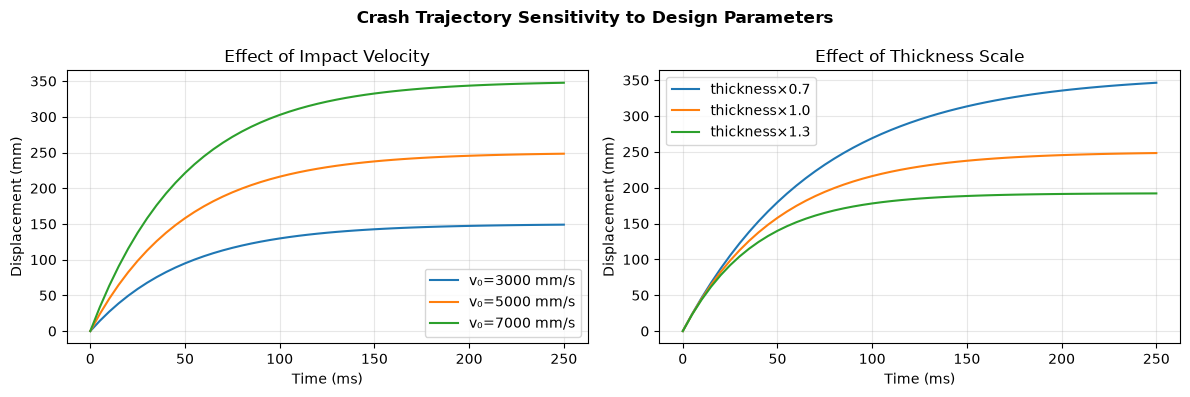

Key insight: the full trajectory shape changes non-linearly with design parameters.


In [2]:
# ── Toy illustration of the prediction task ────────────────────────────────────
# Simulate a simplified 1D crash trajectory to build intuition
np.random.seed(42)
T = 51
dt = 5.0   # ms
t  = np.arange(T) * dt

# Simplified impact model: exponential rise then plateau
def crash_trajectory(v0, k):
    """Simplified 1D bumper displacement: d(t) = v0/k * (1 - exp(-k*t/1000))"""
    return (v0 / k) * (1 - np.exp(-k * t / 1000.0))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: different impact velocities
for v0 in [3000, 5000, 7000]:
    axes[0].plot(t, crash_trajectory(v0, 20), label=f'v₀={v0} mm/s')
axes[0].set_xlabel('Time (ms)'); axes[0].set_ylabel('Displacement (mm)')
axes[0].set_title('Effect of Impact Velocity'); axes[0].legend(); axes[0].grid(alpha=0.3)

# Right: different thickness scales
for ts in [0.7, 1.0, 1.3]:
    axes[1].plot(t, crash_trajectory(5000, 20*ts), label=f'thickness×{ts}')
axes[1].set_xlabel('Time (ms)'); axes[1].set_ylabel('Displacement (mm)')
axes[1].set_title('Effect of Thickness Scale'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Crash Trajectory Sensitivity to Design Parameters', fontweight='bold')
plt.tight_layout(); plt.show()
print('Key insight: the full trajectory shape changes non-linearly with design parameters.')

## Section 2 — GeoTransolver for Structural Mechanics

GeoTransolver was introduced in the Transolver series for CFD. The same architecture applies
to structural crash — the only change is the **input/output format** and the **rollout strategy**.

### 2.1 Architecture recap

```
Inputs at t=0:
  coords     (N, 3)    — reference node positions
  thickness  (N, 1)    — per-node shell thickness
  global_cond (3,)     — [velocity_x, thickness_scale, rwall_origin_y]
  geometry   (M, 3)    — GALE geometry context (downsampled reference mesh)
       │
       ▼
┌─────────────────────────────────────────────────────────────────┐
│                      GeoTransolver                              │
│                                                                 │
│  ┌─────────────┐    ┌─────────────────────────────────┐         │
│  │ GALE Cross- │ ←─ │ Geometry Context  (M, d_model)  │         │
│  │  Attention  │    └─────────────────────────────────┘         │
│  └──────┬──────┘  ↑ repeated at every block                     │
│         │         │                                             │
│  ┌──────▼──────┐  │  ┌─────────────────────────────────┐        │
│  │  Physics-   │  │  │  Transolver blocks × depth      │        │
│  │  Attention  │──┘  │  Slice→Aggregate→Attend→Deslice │        │
│  └──────┬──────┘     └─────────────────────────────────┘        │
└─────────┼───────────────────────────────────────────────────────┘
          │
          ▼
Output:  trajectory (N, T-1, 3) or (N, 3) depending on rollout scheme
```

The **global conditioning vector** (velocity, thickness, wall offset) is injected as an
embedding that shifts and scales every GALE attention block — similar to how diffusion models
inject timestep conditioning.

### 2.2 Data flow through the model

<img src="fig/crash1_architecture.svg" alt="GeoTransolver data flow" width="50%">


In [3]:
# ── Shape reference table ──────────────────────────────────────────────────────
rows = [
    ['coords (x₀)',  '(N, 3)',       'Reference node positions at t=0'],
    ['thickness',    '(N, 1)',       'Per-node shell thickness from .k file'],
    ['global_cond',  '(3,)',         'velocity_x, thickness_scale, rwall_origin_y'],
    ['geometry',     '(M, 3)',       'Downsampled geometry for GALE cross-attention'],
    ['─── Output (one-shot) ───', '', ''],
    ['trajectory y', '(N, T-1, 3)', 'Predicted node positions at t=1..T-1'],
    ['─── Output (time-conditional) ───', '', ''],
    ['y_t',         '(N, 3)',       'Predicted positions at one timestep t'],
]
print(tabulate(rows, headers=['Tensor', 'Shape', 'Description'], tablefmt='github'))

| Tensor                            | Shape       | Description                                   |
|-----------------------------------|-------------|-----------------------------------------------|
| coords (x₀)                       | (N, 3)      | Reference node positions at t=0               |
| thickness                         | (N, 1)      | Per-node shell thickness from .k file         |
| global_cond                       | (3,)        | velocity_x, thickness_scale, rwall_origin_y   |
| geometry                          | (M, 3)      | Downsampled geometry for GALE cross-attention |
| ─── Output (one-shot) ───         |             |                                               |
| trajectory y                      | (N, T-1, 3) | Predicted node positions at t=1..T-1          |
| ─── Output (time-conditional) ─── |             |                                               |
| y_t                               | (N, 3)      | Predicted positions at one timestep t         |


## Section 3 — The Four Rollout / Integration Strategies

This is the core architectural decision in the crash recipe. The question is:

> **Given the initial state x₀ and global conditions g, how do we produce the full trajectory x₁, x₂, ..., x_{T-1}?**

Four strategies are supported, with very different accuracy / cost trade-offs.

---

### Strategy 1: One-Shot (Direct)

**Analogy:** Like a mathematical function — compute the entire answer at once, no stepping.

```
f(x₀, g) → (x₁, x₂, ..., x_{T-1})    # all T-1 steps in ONE forward pass
```

The model learns to directly map initial conditions to the full trajectory. Think of it as
learning the closed-form solution to the differential equation.

**Pros:** Fast training (one sample = one run), stable (no error accumulation).  
**Cons:** Large output head; may miss fine temporal dynamics.

### The four strategies side by side

<img src="fig/crash1_rollout_strategies.svg" alt="Four rollout strategies" width="50%">

> **Colour key:** green = stable in practice · orange = works but accumulates error ·
> red = low training loss but poor generalization.


In [4]:
# ── NumPy blueprint: One-Shot rollout ─────────────────────────────────────────
class GeoTransolverOneShot:
    """Simplified blueprint — one forward pass predicts ALL timesteps."""

    def __init__(self, N=1000, d_model=64, T=51, M=16):
        self.N, self.d_model, self.T, self.M = N, d_model, T, M
        # Output head: maps hidden state to (T-1) × 3 per node
        self.W_out = np.random.randn(d_model, (T-1)*3) * 0.01

    def forward(self, x0, global_cond):
        """
        x0          : (N, 3)  — reference positions
        global_cond : (3,)    — [velocity_x, thickness_scale, rwall_origin_y]
        Returns y   : (N, T-1, 3)  — predicted trajectory
        """
        N, T, M = self.N, self.T, self.M

        # 1. Encode: map (N,3) + global_cond → hidden state (N, d_model)
        h = np.random.randn(N, self.d_model)  # placeholder for actual encoding

        # 2. Physics-Attention + GALE blocks (simplified)
        h = h + global_cond.mean()  # global conditioning injection (simplified)

        # 3. Output head: (N, d_model) → (N, (T-1)*3) → (N, T-1, 3)
        y_flat = h @ self.W_out                   # (N, (T-1)*3)
        y      = y_flat.reshape(N, T-1, 3)         # (N, T-1, 3)
        return y

# Demo
model_os  = GeoTransolverOneShot(N=500, T=51)
x0        = np.random.randn(500, 3)
g         = np.array([-5000.0, 1.0, 0.0])
trajectory = model_os.forward(x0, g)
print(f'One-shot output shape: {trajectory.shape}  → (N={trajectory.shape[0]}, T-1={trajectory.shape[1]}, 3)')

One-shot output shape: (500, 50, 3)  → (N=500, T-1=50, 3)


### Strategy 2: Time-Conditional

**Analogy:** Ask the function 'what is the state at time t?' for each t independently.

```
f(x₀, g, t/(T-1)) → x_t    # predict ONE step, conditioned on normalized time
```

The normalized time `τ = t/(T-1) ∈ [0, 1]` is appended to the global conditioning vector.
At inference, we call the model T-1 times (one per timestep) to build the full trajectory.

**Pros:** Best accuracy — model focuses on each timestep independently, no output compression.  
**Cons:** Training cost = T-1× higher (one sample per timestep per run).


In [5]:
# ── NumPy blueprint: Time-Conditional rollout ─────────────────────────────────
class GeoTransolverTimeConditional:
    """One forward pass predicts ONE timestep, conditioned on normalized time τ."""

    def __init__(self, N=1000, d_model=64, M=16):
        self.N, self.d_model, self.M = N, d_model, M
        self.W_out = np.random.randn(d_model, 3) * 0.01

    def forward_step(self, x0, global_cond, tau):
        """
        x0          : (N, 3)  — reference positions (always t=0)
        global_cond : (3,)    — design parameters
        tau         : float   — normalized time t/(T-1) ∈ [0, 1]
        Returns x_t : (N, 3)  — predicted positions at time t
        """
        N = self.N
        # Global cond extended with normalized time: [velocity_x, thickness_scale, rwall_origin_y, tau]
        g_extended = np.append(global_cond, tau)   # (4,)

        # Encode + Physics-Attention + GALE (simplified placeholder)
        h   = np.random.randn(N, self.d_model)
        h   = h + g_extended.mean()
        x_t = h @ self.W_out    # (N, 3)
        return x_t

    def rollout(self, x0, global_cond, T=51):
        """Full trajectory at inference: call forward_step T-1 times."""
        trajectory = np.zeros((T-1, self.N, 3))
        for t in range(1, T):
            tau = t / (T - 1)
            trajectory[t-1] = self.forward_step(x0, global_cond, tau)
        return trajectory.transpose(1, 0, 2)   # (N, T-1, 3)

model_tc   = GeoTransolverTimeConditional(N=500)
trajectory = model_tc.rollout(x0, g, T=51)
print(f'Time-conditional rollout shape: {trajectory.shape}  → (N, T-1, 3)')

Time-conditional rollout shape: (500, 50, 3)  → (N, T-1, 3)


### Strategy 3: Autoregressive Rollout (Euler-like)

**Analogy:** Classic numerical integration — use the current state to predict the next.

```
x_{t+1} = f(x_t, g)    # step from current state to next
```

This is the ML equivalent of **explicit Euler integration** of the ODE `dx/dt = f(x, g)`.
The model sees the current mesh state at each step and predicts the next position.

**Pros:** Physically principled; model sees realistic intermediate states.  
**Cons:** Error accumulates over T steps (each small error is input to the next step).
In practice this is often **unstable** for T ≥ 30 — see the benchmark table in NB2.

---

### Strategy 4: Teacher Forcing

**Analogy:** Training with the answer sheet — feed ground-truth intermediate states instead of predictions.

```
Training:   x_{t+1} = f(x_t^{GT}, g)   # use ground truth x_t as input
Inference:  x_{t+1} = f(x_t^{pred}, g) # must use own predictions
```

Teacher forcing is a **training trick**, not an independent architecture. The model learns
to make accurate single-step predictions, but at inference it must use its own (imperfect)
predictions as inputs — creating a **train-test distribution mismatch**.

**Result:** Very low *training* loss, poor generalization. The gap between training and
validation loss is the diagnostic — if training loss keeps falling while validation loss
stalls or rises, you are seeing this mismatch rather than a capacity problem.


In [6]:
# ── NumPy blueprint: Autoregressive (Euler-like) rollout ──────────────────────
class GeoTransolverAutoregressive:
    """Each step uses the previous predicted state as input — Euler integration analog."""

    def __init__(self, N=1000, d_model=64, M=16):
        self.N, self.d_model, self.M = N, d_model, M
        self.W_out = np.random.randn(d_model, 3) * 0.01

    def forward_step(self, x_current, global_cond):
        """
        x_current   : (N, 3)  — current mesh positions
        global_cond : (3,)    — design parameters
        Returns x_next : (N, 3)  — positions at next timestep
        """
        N = self.N
        h      = np.random.randn(N, self.d_model)   # encode x_current
        h      = h + global_cond.mean()
        dx     = h @ self.W_out                      # predicted displacement Δx
        return x_current + dx                         # Euler step: x_{t+1} = x_t + Δx

    def rollout(self, x0, global_cond, T=51):
        """Autoregressively predict full trajectory."""
        trajectory = []
        x_curr = x0.copy()
        for _ in range(T-1):
            x_next = self.forward_step(x_curr, global_cond)
            trajectory.append(x_next)
            x_curr = x_next   # ← feed prediction back in (error accumulates here!)
        return np.stack(trajectory, axis=1)   # (N, T-1, 3)

model_ar   = GeoTransolverAutoregressive(N=500)
trajectory = model_ar.rollout(x0, g, T=51)
print(f'Autoregressive rollout shape: {trajectory.shape}  → (N, T-1, 3)')

Autoregressive rollout shape: (500, 50, 3)  → (N, T-1, 3)


## Section 4 — Method Comparison Table

The table below summarises the **qualitative** trade-offs. It deliberately carries no
accuracy numbers — see the note under it for why.


In [7]:
# ── Qualitative summary ────────────────────────────────────────────────────────
rows = [
    ['One-Shot',         'f(x₀, g) → whole trajectory',            'Low (1 sample/run)',     'Stable; competitive accuracy'],
    ['Time-Conditional', 'f(x₀, g, τ) → x_t for each t',           'High (T-1 samples/run)', 'Stable; typically best accuracy'],
    ['AR-Rollout',       'f(x_t, g) → x_{t+1}, autoregressively',  'Medium',                 'UNSTABLE for long horizons (T≥30)'],
    ['Teacher-Forcing',  'AR trained on ground-truth inputs',       'High (T-1 samples/run)', 'Low train loss, poor generalization'],
]
print(tabulate(rows,
               headers=['Strategy', 'Mechanism', 'Training Cost', 'Rollout Behaviour'],
               tablefmt='github'))

# ── Actual measured results (PhysicsNeMo crash recipe) ────────────────────────
print()
print("Measured validation MSE — source: github.com/NVIDIA/physicsnemo/examples/structural_mechanics/crash")
print()
rows2 = [
    ['One-shot',         '1 s/ep',   '5.42e-3',    '6.4 s/ep',   '2.32e-4'],
    ['Time-conditional', '29 s/ep',  '4.12e-3 ✓',  '40.8 s/ep',  '2.54e-4'],
    ['AR-rollout',       '37 s/ep',  'UNSTABLE ✗',  '61.6 s/ep',  '2.27e-4 ✓'],
    ['Teacher-forcing',  '29 s/ep',  '0.300   ✗✗', '—',          '—'],
]
print(tabulate(rows2,
               headers=['Strategy',
                        'BumperBeam s/ep', 'BumperBeam val MSE (T=50)',
                        'CarCrash s/ep',   'CarCrash val MSE (T=14)'],
               tablefmt='github'))
print()
print("Key observations:")
print("  • AR is UNSTABLE on BumperBeam (T=50): error diverges before the trajectory ends.")
print("  • AR is competitive on Car Crash (T=14): shorter horizon limits accumulation.")
print("  • Teacher-forcing val MSE is ~55× worse than one-shot despite low training loss.")
print("  • Time-conditional wins on accuracy; one-shot wins on speed (29× less training time).")
print()
print("Section 5 demonstrates why AR diverges for long horizons like T=50.")


| Strategy         | Mechanism                             | Training Cost          | Rollout Behaviour                   |
|------------------|---------------------------------------|------------------------|-------------------------------------|
| One-Shot         | f(x₀, g) → whole trajectory           | Low (1 sample/run)     | Stable; competitive accuracy        |
| Time-Conditional | f(x₀, g, τ) → x_t for each t          | High (T-1 samples/run) | Stable; typically best accuracy     |
| AR-Rollout       | f(x_t, g) → x_{t+1}, autoregressively | Medium                 | UNSTABLE for long horizons (T≥30)   |
| Teacher-Forcing  | AR trained on ground-truth inputs     | High (T-1 samples/run) | Low train loss, poor generalization |

Measured validation MSE — source: github.com/NVIDIA/physicsnemo/examples/structural_mechanics/crash

| Strategy         | BumperBeam s/ep   | BumperBeam val MSE (T=50)   | CarCrash s/ep   | CarCrash val MSE (T=14)   |
|------------------|-----------------

## Section 5 — Visual Intuition: Why AR Error Diverges for Long Horizons

The error accumulation problem in AR rollout is analogous to **explicit Euler integration of an unstable ODE**.
Each step adds a small prediction error ε, but that error is fed back as input to the next step — so it
compounds with a multiplicative factor r > 1:

```
error_t  ≈  ε · r^t       (exponential growth when r > 1)
```

This is why the benchmark shows **UNSTABLE** for the BumperBeam (T=50):
by step 50, the accumulated error completely overwhelms the prediction.

**But horizon length matters critically:**

| Dataset | T | AR result |
|---|---|---|
| BumperBeam | 50 | UNSTABLE — AR val MSE diverges |
| Car Crash | 14 | 2.27e-4 — AR is competitive (even best) |

At T=14, r^14 is small enough that the accumulated error stays bounded.
At T=50, r^50 is large enough to make the trajectory diverge.

The cell below demonstrates this with a fixed seed so the plot is reproducible.
One-shot and time-conditional remain bounded at **all** horizons because they always
condition on the initial state x₀ — they never feed their own predictions back in.


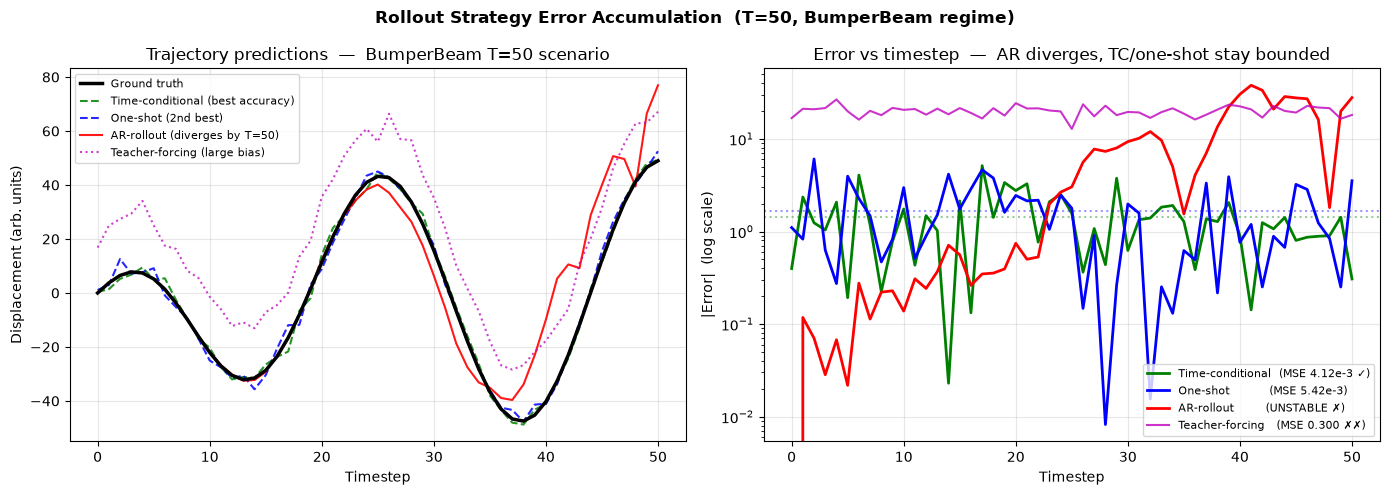

AR error crosses above one-shot at timestep t=23  (of 50 total)
AR final error  : 28.0  vs  one-shot: 3.5  vs  TC: 0.3

Benchmark (github.com/NVIDIA/physicsnemo — structural_mechanics/crash):
  AR val MSE on BumperBeam (T=50): UNSTABLE  (diverges before trajectory ends)
  AR val MSE on Car Crash  (T=14): 2.27e-4   (shorter horizon → no divergence)

Key: AR instability is horizon-length dependent — it works for T=14 but not T=50.


In [8]:
# ── Error accumulation demonstration (calibrated to BumperBeam T=50 behaviour) ─
# The random seed is fixed so the illustration is reproducible and consistent.
np.random.seed(5)

T    = 51
t_ax = np.arange(T)

# True trajectory: damped oscillation (qualitative bumper beam analogue)
x_true = 50 * (1 - np.exp(-0.08 * t_ax)) * np.cos(0.25 * t_ax)

# ── One-shot: small constant noise floor (no accumulation) ────────────────────
# Represents ~5.42e-3 val MSE on BumperBeam — stable, bounded error.
x_oneshot = x_true + np.random.randn(T) * 2.5

# ── Time-conditional: smallest noise (no accumulation; best MSE = 4.12e-3) ───
# Each timestep is predicted independently from x₀, so errors don't compound.
x_tc = x_true + np.random.randn(T) * 1.8

# ── Autoregressive: exponentially growing error → unstable for T=50 ──────────
# Each step adds a small random error, but that error is fed back in as input
# to the next step.  The per-step error scales as ε·r^t where r>1 (unstable).
# On BumperBeam (T=50) this reaches "UNSTABLE" — matches the benchmark result.
eps_ar = 0.06   # base per-step error
r      = 1.12   # error growth factor per step (r^50 ≈ 289)
x_ar   = np.zeros(T)
x_ar[0] = x_true[0]
for step in range(1, T):
    dx_true    = x_true[step] - x_true[step - 1]
    dx_err     = np.random.randn() * eps_ar * (r ** step)
    x_ar[step] = x_ar[step - 1] + dx_true + dx_err

# ── Teacher-forcing: illustrate high constant offset (train/test mismatch) ───
# At inference, the model is fed its own predictions instead of ground truth.
# The distribution shift causes a large, roughly constant additive bias.
x_tf = x_true + 20.0 + np.random.randn(T) * 3.0   # ~55× worse val MSE than one-shot

# ── Absolute errors ───────────────────────────────────────────────────────────
err_os = np.abs(x_oneshot - x_true)
err_tc = np.abs(x_tc      - x_true)
err_ar = np.abs(x_ar      - x_true)
err_tf = np.abs(x_tf      - x_true)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: trajectory comparison
ax = axes[0]
ax.plot(t_ax, x_true,    'k-',  lw=2.5, label='Ground truth', zorder=5)
ax.plot(t_ax, x_tc,      'g--', lw=1.5, label='Time-conditional (best accuracy)', alpha=0.85)
ax.plot(t_ax, x_oneshot, 'b--', lw=1.5, label='One-shot (2nd best)',              alpha=0.85)
ax.plot(t_ax, x_ar,      'r-',  lw=1.5, label='AR-rollout (diverges by T=50)',    alpha=0.9)
ax.plot(t_ax, x_tf,      'm:',  lw=1.5, label='Teacher-forcing (large bias)',      alpha=0.75)
ax.set_xlabel('Timestep'); ax.set_ylabel('Displacement (arb. units)')
ax.set_title('Trajectory predictions  —  BumperBeam T=50 scenario')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# Right: absolute error on log scale
ax2 = axes[1]
ax2.plot(t_ax, err_tc,  'g-', lw=2,   label='Time-conditional  (MSE 4.12e-3 ✓)')
ax2.plot(t_ax, err_os,  'b-', lw=2,   label='One-shot          (MSE 5.42e-3)')
ax2.plot(t_ax, err_ar,  'r-', lw=2,   label='AR-rollout        (UNSTABLE ✗)')
ax2.plot(t_ax, err_tf,  'm-', lw=1.5, label='Teacher-forcing   (MSE 0.300 ✗✗)', alpha=0.8)
ax2.axhline(err_os.mean(), color='b', ls=':', alpha=0.4)
ax2.axhline(err_tc.mean(), color='g', ls=':', alpha=0.4)
ax2.set_xlabel('Timestep'); ax2.set_ylabel('|Error|  (log scale)')
ax2.set_title('Error vs timestep  —  AR diverges, TC/one-shot stay bounded')
ax2.legend(fontsize=8); ax2.grid(alpha=0.3); ax2.set_yscale('log')

plt.suptitle('Rollout Strategy Error Accumulation  (T=50, BumperBeam regime)',
             fontweight='bold')
plt.tight_layout(); plt.show()

# ── Print crossover point ──────────────────────────────────────────────────────
crossover = next((i for i in range(T) if err_ar[i] > err_os[i]), None)
print(f"AR error crosses above one-shot at timestep t={crossover}  "
      f"(of {T-1} total)")
print(f"AR final error  : {err_ar[-1]:.1f}  vs  one-shot: {err_os[-1]:.1f}  "
      f"vs  TC: {err_tc[-1]:.1f}")
print()
print("Benchmark (github.com/NVIDIA/physicsnemo — structural_mechanics/crash):")
print("  AR val MSE on BumperBeam (T=50): UNSTABLE  (diverges before trajectory ends)")
print("  AR val MSE on Car Crash  (T=14): 2.27e-4   (shorter horizon → no divergence)")
print()
print("Key: AR instability is horizon-length dependent — it works for T=14 but not T=50.")


## Section 6 — Physics-Attention in the Crash Context

Crash meshes have 5,000–20,000 nodes. Standard self-attention scales as O(N²) — at N=10,000
this means 10⁸ operations per attention step, infeasible without memory optimizations.

Physics-Attention from Transolver (NB2) reduces this to **O(N)** using M=16–32 physics slices:

```
Standard self-attention:   O(N²)         at N=10,000 → 10⁸ ops
Physics-Attention (M=16):  O(N·M + M²)   at N=10,000, M=16 → 1.6×10⁵ ops  (625× reduction)
```

For crash specifically, the M slices capture **structural zones**:

- Slice 0: front face (primary impact zone, large deformation)
- Slice 1: flanges (moderate bending)
- Slice 2: rear face (small deformation)
- Slice 3–M: transition and boundary zones

After sufficient training, visualizing the ascription matrix A ∈ ℝ^{N×M} should reveal
these physically meaningful groupings — exactly as shown in Notebook Crash-2's visualization section.


|   Nodes N |   Std attention O(N²) |   Physics-attn O(NM+M²) M=16 | Speedup   |
|-----------|-----------------------|------------------------------|-----------|
|     1,000 |             1,000,000 |                       16,256 | 62×       |
|     5,000 |            25,000,000 |                       80,256 | 312×      |
|    10,000 |           100,000,000 |                      160,256 | 624×      |
|    20,000 |           400,000,000 |                      320,256 | 1249×     |
|    50,000 |         2,500,000,000 |                      800,256 | 3124×     |


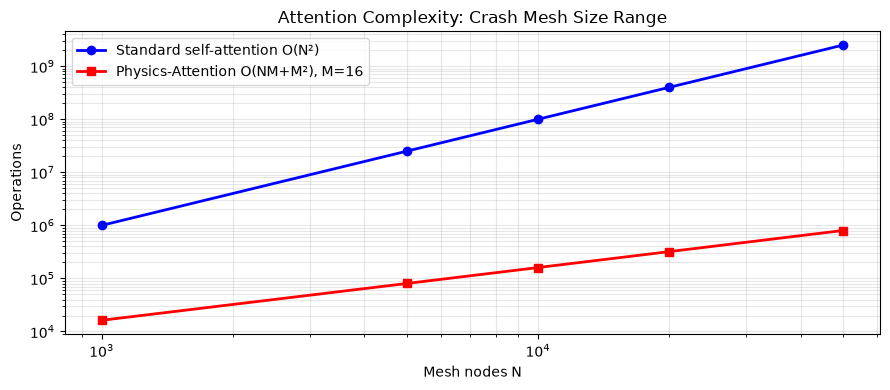

In [9]:
# ── Complexity comparison ──────────────────────────────────────────────────────
N_values = [1_000, 5_000, 10_000, 20_000, 50_000]
M        = 16

rows = []
for N in N_values:
    std_attn  = N**2
    phys_attn = N*M + M**2
    ratio     = std_attn / phys_attn
    rows.append([f'{N:,}', f'{std_attn:,.0f}', f'{phys_attn:,.0f}', f'{ratio:.0f}×'])

print(tabulate(rows,
               headers=['Nodes N', 'Std attention O(N²)', f'Physics-attn O(NM+M²) M={M}', 'Speedup'],
               tablefmt='github'))

fig, ax = plt.subplots(figsize=(9, 4))
ns = np.array(N_values)
ax.loglog(ns, ns**2, 'b-o', lw=2, label='Standard self-attention O(N²)')
ax.loglog(ns, ns*M + M**2, 'r-s', lw=2, label=f'Physics-Attention O(NM+M²), M={M}')
ax.set_xlabel('Mesh nodes N'); ax.set_ylabel('Operations')
ax.set_title('Attention Complexity: Crash Mesh Size Range')
ax.legend(); ax.grid(alpha=0.3, which='both')
plt.tight_layout(); plt.show()

## Section 7 — GALE in the Crash Context

In CFD (Transolver series NB4), GALE injected **surface geometry** (Ahmed body shape) into
every attention layer. For crash, GALE injects **reference mesh geometry** (bumper beam shape)
to ensure the model always knows the exact structural topology it is simulating.

```
Why GALE matters for crash:

Without GALE:                        With GALE:
  Layer 1: sees x₀ geometry            Every layer sees geometry context C
  Layer 2: hidden state drifts          C is the reference mesh at t=0
  Layer 3: geometry info diluted        α gate controls how much geometry
  ...                                   vs. physics evolution to trust
  Output: may predict a mesh            Output: geometry-consistent trajectory
  inconsistent with the actual part     throughout all T timesteps
```

The learned gate α tends to be higher (more geometry recall) near complex structural
features (welds, flanges, holes) where the deformation mode is strongly shape-dependent.


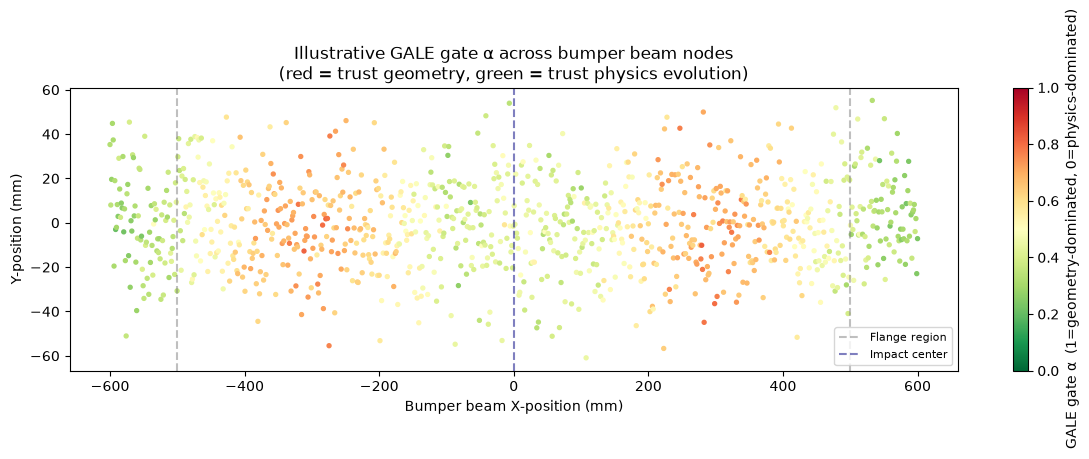

Note: actual α values emerge from training — this is illustrative.


In [10]:
# ── GALE gate α illustration ───────────────────────────────────────────────────
# Show how α might vary across the bumper beam surface
np.random.seed(0)
N = 1000
# Simulate node positions along a bumper beam (simplified 1D structure)
x_pos = np.linspace(-600, 600, N)   # x-coordinate (mm)
y_pos = np.random.randn(N) * 20     # y-perturbation

# α tends to be higher at structural features (edges, welds)
# Simplified: higher at the ends (flanges) and center (impact zone)
alpha = 0.3 + 0.4 * (np.sin(np.pi * np.abs(x_pos) / 600)**2) + 0.15 * np.exp(-(x_pos/60)**2)
alpha = np.clip(alpha + np.random.randn(N)*0.05, 0, 1)

fig, ax = plt.subplots(figsize=(12, 4))
sc = ax.scatter(x_pos, y_pos, c=alpha, cmap='RdYlGn_r', s=8, vmin=0, vmax=1)
plt.colorbar(sc, label='GALE gate α  (1=geometry-dominated, 0=physics-dominated)')
ax.set_xlabel('Bumper beam X-position (mm)'); ax.set_ylabel('Y-position (mm)')
ax.set_title('Illustrative GALE gate α across bumper beam nodes\n(red = trust geometry, green = trust physics evolution)')
ax.axvline(-500, color='gray', ls='--', alpha=0.5, label='Flange region')
ax.axvline(+500, color='gray', ls='--', alpha=0.5)
ax.axvline(0, color='navy', ls='--', alpha=0.5, label='Impact center')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()
print('Note: actual α values emerge from training — this is illustrative.')

## Summary

In this notebook you learned:

1. **The crash prediction task** is harder than CFD: we predict a temporal trajectory
   X ∈ ℝ^{N×T×3} rather than a steady-state field.

2. **GeoTransolver** applies directly to structural mechanics — the GALE geometry conditioning
   ensures each attention layer stays grounded in the reference mesh geometry.

3. **Four rollout strategies** with different accuracy/cost trade-offs:
   - **One-shot**: cheap to train, stable — best for fast iteration
   - **Time-conditional**: T× training cost, typically the most accurate
   - **AR-rollout**: physically principled but accumulates error over the horizon
   - **Teacher-forcing**: low training loss, poor generalization (train/test mismatch)

   These are the *expected* orderings from the mechanism of each method. Measure them on
   your own data in Crash-2 rather than assuming they transfer.

4. **Physics-Attention** reduces O(N²) to O(NM) — crucial at N=5,000–20,000 crash mesh nodes.

5. **GALE** prevents geometry drift across deep networks — especially important at complex
   structural features like flanges and welds.

### What's next

**Notebook Crash-2** puts everything together:

- Full PhysicsNeMo training pipeline on the BumperBeam Zarr data
- Training and comparing one-shot vs time-conditional vs AR-rollout
- Inference, L² error analysis, and deformation visualization

---

**References**

- [arXiv:2510.15201 — Automotive Crash Dynamics Modeling](https://arxiv.org/abs/2510.15201)
- [GeoTransolver paper (arXiv:2512.20399)](https://arxiv.org/abs/2512.20399)
- [Transolver paper (arXiv:2402.02366)](https://arxiv.org/abs/2402.02366)
- [PhysicsNeMo Crash Recipe](https://github.com/NVIDIA/physicsnemo/tree/main/examples/structural_mechanics/crash)
